In [10]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
import tensorflow as tf
import random as rn
from sklearn.metrics import accuracy_score, precision_score, recall_score, log_loss,f1_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import pywt
from skimage.transform import resize
# Reproducibility
sd = 1
os.environ['PYTHONHASHSEED'] = str(sd)
np.random.seed(sd)
rn.seed(sd)
tf.random.set_seed(sd)

# Root directory containing data folders
root_dir = './Paderborn_PreCase1_Data'

# Class label structure
data_structure = {
    0: ("Healthy", ["K001", "K002", "K003", "K004", "K005"]),
    1: ("OR_Damage", ["KA04", "KA15", "KA16", "KA22", "KA30"]),
    2: ("IR_Damage", ["KI04", "KI14", "KI16", "KI18", "KI21"]),
}

sample_limit_per_label = {0: 256000, 1: 5120, 2: 5120}

# Extract vibration signal from .mat file
def extract_signals_df(filepath, signal="vibration"):
    signals = {"vibration": 6, "current_1": 1, "current_2": 2}
    mat = loadmat(filepath, struct_as_record=False, squeeze_me=True)
    field = next(k for k in mat if not k.startswith("__"))
    struct = mat[field]
    X_channels = struct.X
    Y_channels = struct.Y
    v = Y_channels[signals["vibration"]].Data.flatten().reshape(-1, 1)
    return pd.DataFrame(v, columns=["vibration"])

# Data extraction
all_data = {0: [], 1: [], 2: []}

for label, (category, folders) in data_structure.items():
    for folder in folders:
        folder_path = os.path.join(root_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} not found.")
            continue

        mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
        if not mat_files:
            print(f"No .mat files found in {folder_path}")
            continue

        filename = mat_files[0]
        file_path = os.path.join(folder_path, filename)
        try:
            df = extract_signals_df(file_path, signal="vibration")
            df = df.iloc[:sample_limit_per_label[label]].copy()
            df["label"] = label
            all_data[label].append(df)
            print(f"Loaded {file_path} with {len(df)} samples.")
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# Combine all data
final_df = pd.concat([df for dfs in all_data.values() for df in dfs], ignore_index=True)
final_df.rename(columns={"vibration": "signal"}, inplace=True)
print("\nCombined data shape:", final_df.shape)
print(final_df.head())

# Signal grouping
df_signals = final_df[["signal", "label"]].copy()
grouped_signals = [
    df_signals[df_signals['label'] == i]['signal'].values.astype(float)
    for i in sorted(df_signals['label'].unique())
]



# Datapoints per group
# print("\n Count of samples in each group")
for idx, signal_array in enumerate(grouped_signals):
    class_name = data_structure[idx][0]
    print(f"Class {idx} ({class_name}) - Number of samples: {len(signal_array)}")


Loaded ./Paderborn_PreCase1_Data/K001/N15_M07_F04_K001_13.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K002/N09_M07_F10_K002_2.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K003/N09_M07_F10_K003_1.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K004/N09_M07_F10_K004_2.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K005/N09_M07_F10_K005_1.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/KA04/N09_M07_F10_KA04_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA15/N09_M07_F10_KA15_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA16/N09_M07_F10_KA16_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA22/N09_M07_F10_KA22_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA30/N09_M07_F10_KA30_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KI04/N09_M07_F10_KI04_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KI14/N09_M07_F10_KI14_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_D

In [11]:

# Data preparation
def Sampling(Data, interval_length, samples_per_block, ignore_points=0):
    adjusted_length = len(Data) - 2 * ignore_points
    No_of_blocks = (
        round(adjusted_length / interval_length)
        - round(samples_per_block / interval_length)
        - 1
    )
    if No_of_blocks <= 0:
        return np.empty((0, samples_per_block))
    SplitData = np.zeros([No_of_blocks, samples_per_block])
    for i in range(No_of_blocks):
        start_idx = ignore_points + i * interval_length
        SplitData[i, :] = Data[start_idx : start_idx + samples_per_block].T
    return SplitData

def DataPreparation(DataList, interval_length, samples_per_block):
    segment_list = []
    one_hot_labels = []
    integer_labels = []
    for count, signal in enumerate(DataList):
        SplitData = Sampling(signal, interval_length, samples_per_block)
        segments = SplitData.shape[0]
        
        print(f"\nClass: {count} Fault Label: {data_structure[count][0]}")
        print(f"Segments: {segments} segments")
        print(f"Sample data (first 5 elements): {SplitData[0][:5] if segments > 0 else 'Empty'}")
        
        
        if SplitData.shape[0] == 0:
            continue
        segment_list.append(SplitData)

        one_hot = np.zeros((segments, len(DataList)))
        one_hot[:, count] = 1
        one_hot_labels.append(one_hot)

        int_labels = np.full((segments, 1), count)
        integer_labels.append(int_labels)
        
        y = np.zeros([len(SplitData), len(DataList)])
        y[:, count] = 1
        y1 = np.zeros([len(SplitData), 1])
        y1[:, 0] = count
        if count == 0:
            X = SplitData
            LabelPositional = y
            Label = y1
        else:
            X = np.append(X, SplitData, axis=0)
            LabelPositional = np.append(LabelPositional, y, axis=0)
            Label = np.append(Label, y1, axis=0)
    # return X, LabelPositional, Label
    return segment_list, one_hot_labels, integer_labels

# Run preparation
# X_train, y_train_positional, y_train = DataPreparation(grouped_signals, interval_length, samples_per_block)



In [12]:
def generate_scalogram(segment, image_shape, fs=48000, scales=np.arange(1, 128), wavelet='morl'):
    coeffs, freqs = pywt.cwt(segment, scales, wavelet, sampling_period=1/fs)
    scalogram = np.abs(coeffs)
    scalogram = (scalogram - np.min(scalogram)) / (np.max(scalogram) - np.min(scalogram))  # Normalize
    scalogram = resize(scalogram, image_shape, mode='constant', anti_aliasing=True)
    return scalogram

In [13]:

# Updated per-file DataPreparation with time-based split
def process_each_mat_file_separately(data_structure, root_dir, interval_length, samples_per_block, train_ratio, sample_limit_per_label,image_shape):
    all_train_segments, all_test_segments = [], []
    all_train_labels_positional, all_test_labels_positional = [], []
    all_train_labels, all_test_labels = [], []
    segment_counts = {0: 0, 1: 0, 2: 0}
   
    
    for label, (label_name, folders) in data_structure.items():
        for folder in folders:
            folder_path = os.path.join(root_dir, folder)
            mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
            if not mat_files:
                continue
            mat_path = os.path.join(folder_path, mat_files[0])
            df = extract_signals_df(mat_path)
            df = df.iloc[:sample_limit_per_label[label]].copy()
            signal = df["vibration"].values.flatten()

            # Sampling
            segments = Sampling(signal, interval_length, samples_per_block)

            scalograms = np.array([generate_scalogram(seg, image_shape, fs=48000) for seg in segments])
            
            segment_counts[label] += segments.shape[0]
            if segments.shape[0] == 0:
                continue
            n_segments = segments.shape[0]
            split_idx = int(n_segments * train_ratio)

            train_segments = scalograms[:split_idx]
            test_segments = scalograms[split_idx:]

            y_train_pos = np.zeros((train_segments.shape[0], len(data_structure)))
            y_train_pos[:, label] = 1
            y_train = np.full((train_segments.shape[0], 1), label)

            y_test_pos = np.zeros((test_segments.shape[0], len(data_structure)))
            y_test_pos[:, label] = 1
            y_test = np.full((test_segments.shape[0], 1), label)

            all_train_segments.append(train_segments)
            all_test_segments.append(test_segments)
            all_train_labels_positional.append(y_train_pos)
            all_test_labels_positional.append(y_test_pos)
            all_train_labels.append(y_train)
            all_test_labels.append(y_test)

    print("\nSegmented dataset shape:")
    for label in sorted(segment_counts.keys()):
        fault_label = data_structure[label][0]
        print(f"Class: {label} Fault Label: {fault_label} Segments: {segment_counts[label]} segments")
        
    # Final combine
    X_train = np.vstack(all_train_segments).reshape([-1, *image_shape, 1])
    X_test = np.vstack(all_test_segments).reshape([-1, *image_shape, 1])
    Y_train = np.vstack(all_train_labels_positional)
    Y_test = np.vstack(all_test_labels_positional)
    y_train = np.vstack(all_train_labels)
    y_test = np.vstack(all_test_labels)

    return X_train, X_test, Y_train, Y_test, y_train, y_test


In [15]:
# Split into training and test sets (80% train, 20% test)
# X_train_split, X_test_split, y_train_positional_split, y_test_positional_split = train_test_split(
#     X_train, y_train_positional, test_size=0.2, random_state=sd, stratify=y_train)

train_ratio = 0.8
n_classes = 3

# Parameters
interval_length = 320
samples_per_block = 1600
n_classes = 3  # Healthy, OR, IR
image_shape=(96, 96)

X_train_split, X_test_split, y_train_positional_split, y_test_positional_split, y_label_train, y_label_test = process_each_mat_file_separately(
    data_structure, root_dir, interval_length, samples_per_block, train_ratio=0.8, sample_limit_per_label=sample_limit_per_label, image_shape=image_shape
)

input_shape = (96, 96, 1)   # Reshaped input for CNN 2D
# print(f"\nInput Shape: {input_shape}")

# Convert one-hot labels to class indices
y_train_labels = np.argmax(y_train_positional_split, axis=1)
y_test_labels = np.argmax(y_test_positional_split, axis=1)

# Count samples per class
unique_train, counts_train = np.unique(y_label_train, return_counts=True)
unique_test, counts_test = np.unique(y_label_test, return_counts=True)

print("\nClass distribution in training set:")
for label, count in zip(unique_train, counts_train):
    print(f"Class {label}: {count} samples")

print("\nClass distribution in test set:")
for label, count in zip(unique_test, counts_test):
    print(f"Class {label}: {count} samples")

print("Train label distribution:", np.bincount(y_label_train.flatten().astype(int)))
print("Test label distribution:", np.bincount(y_label_test.flatten().astype(int)))

# Reshape data to 2D for CNN input
X_2D_train = X_train_split
X_2D_test = X_test_split

print(f"\nX_2D_train shape: {X_2D_train.shape}")
print(f"Y_train shape: {y_train_positional_split.shape}")
print(f"X_2D_test shape: {X_2D_test.shape}")
print(f"Y_test shape: {y_test_positional_split.shape}")



Segmented dataset shape:
Class: 0 Fault Label: Healthy Segments: 3970 segments
Class: 1 Fault Label: OR_Damage Segments: 50 segments
Class: 2 Fault Label: IR_Damage Segments: 50 segments

Class distribution in training set:
Class 0: 3175 samples
Class 1: 40 samples
Class 2: 40 samples

Class distribution in test set:
Class 0: 795 samples
Class 1: 10 samples
Class 2: 10 samples
Train label distribution: [3175   40   40]
Test label distribution: [795  10  10]

X_2D_train shape: (3255, 96, 96, 1)
Y_train shape: (3255, 3)
X_2D_test shape: (815, 96, 96, 1)
Y_test shape: (815, 3)


In [19]:
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import layers, models, optimizers
from keras_tuner.tuners import RandomSearch
from kerastuner import HyperModel
from tensorflow.keras import layers, models, optimizers

class CNN2DHyperModel(HyperModel):
    def __init__(self, input_shape, num_classes):
        self.input_shape = input_shape
        self.num_classes = num_classes

    def build(self, hp):
        model = models.Sequential()

        # Conv Block 1
        model.add(layers.Conv2D(
            filters=hp.Choice('conv1_filters', [16, 32, 64]),
            kernel_size=hp.Choice('conv1_kernel', [3, 5]),
            activation=hp.Choice('activation', ['relu', 'swish']),
            padding='same',
            input_shape=self.input_shape))

        model.add(layers.Conv2D(
            filters=hp.Choice('conv1_filters_2', [16, 32, 64]),
            kernel_size=hp.Choice('conv1_kernel_2', [3, 5]),
            activation=hp.Choice('activation', ['relu', 'swish']),
            padding='same'))

        if hp.Boolean("use_batchnorm_1"):
            model.add(layers.BatchNormalization())

        model.add(layers.MaxPool2D(pool_size=(2, 2), padding='same'))

        # Conv Block 2
        model.add(layers.Conv2D(
            filters=hp.Choice('conv2_filters', [32, 64, 128]),
            kernel_size=3,
            activation=hp.Choice('activation', ['relu', 'swish']),
            padding='same'))

        model.add(layers.Conv2D(
            filters=hp.Choice('conv2_filters_2', [32, 64, 128]),
            kernel_size=3,
            activation=hp.Choice('activation', ['relu', 'swish']),
            padding='same'))

        if hp.Boolean("use_batchnorm_2"):
            model.add(layers.BatchNormalization())

        model.add(layers.MaxPool2D(pool_size=(2, 2), padding='same'))

        # Final layers
        model.add(layers.GlobalAveragePooling2D())
        model.add(layers.Dense(
            units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
            activation=hp.Choice('activation', ['relu', 'swish'])
        ))
        model.add(layers.Dropout(hp.Float('dropout_rate', 0.2, 0.5, step=0.1)))
        model.add(layers.Dense(self.num_classes, activation='softmax'))

        model.compile(
            optimizer=optimizers.Adam(
                learning_rate=hp.Choice('learning_rate', [0.01, 0.001, 0.0001])
            ),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        return model
        
tuner = kt.RandomSearch(
    CNN2DHyperModel(input_shape=(96, 96, 1), num_classes=3),  # Adjust shape/classes
    objective='val_accuracy',
    max_trials=10,  # Total combinations to try
    executions_per_trial=1,  # Repeat training to reduce variance
    directory='Paderborn_results',
    project_name='scalogram_hyperparam_tuning'
)

tuner.search_space_summary()

early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

tuner.search(
    X_2D_train, y_train_positional_split,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\nBest Hyperparameters:")
for hp in best_hps.values:
    print(f"{hp}: {best_hps.get(hp)}")

test_loss, test_acc = best_model.evaluate(X_2D_test, y_test_positional_split)
print(f"\nTest Accuracy of best model: {test_acc:.4f}")



Trial 10 Complete [00h 07m 50s]
val_accuracy: 0.8771121501922607

Best val_accuracy So Far: 0.8771121501922607
Total elapsed time: 03h 34m 36s


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Best Hyperparameters:
conv1_filters: 64
conv1_kernel: 5
activation: relu
conv1_filters_2: 32
conv1_kernel_2: 3
use_batchnorm_1: True
conv2_filters: 128
conv2_filters_2: 128
use_batchnorm_2: True
dense_units: 96
dropout_rate: 0.30000000000000004
learning_rate: 0.0001
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.9980 - loss: 0.0798

Test Accuracy of best model: 0.9755


In [22]:
class CNN_2D():
    def __init__(self):
        self.model = self.CreateModel()
        self.model.summary()

    def CreateModel(self):
        model = models.Sequential([
            layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', activation='relu', input_shape=input_shape),
            layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', activation='relu', input_shape=input_shape),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            layers.Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),

            layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            layers.Conv2D(filters=128, kernel_size=(3,3), strides=1, padding ='same', activation='relu'),
            layers.Conv2D(filters=128, kernel_size=(3,3), strides=1, padding ='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),

            # layers.Flatten(),
            # layers.Dense(100,activation='relu'),
            # layers.Dense(50,activation='relu'),
            # layers.Dense(3, activation='softmax')

            layers.GlobalAveragePooling2D(),
            layers.Dense(96, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(3, activation='softmax')

            # Flatten(),  # Output: (None, 5 * 5 * 128) = (None, 3200)
            # Dense(128, activation='relu'),  # Accepts 3200 units
            # Dropout(0.5),
            # Dense(10, activation='softmax')  # 10 classes

            
        ])

        # Optimizer with a slightly higher learning rate
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss=tf.keras.losses.CategoricalCrossentropy(),
                      metrics=['accuracy'])
        return model

In [27]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels),
    y=y_labels
)

# Convert to dictionary
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(0.3417322834645669), 1: np.float64(27.125), 2: np.float64(27.125)}


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

 Trainable params: 306,387 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 18s 200ms/step - accuracy: 0.9222 - loss: 0.2259 - val_accuracy: 0.9754 - val_loss: 0.1357
Epoch 2/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9795 - loss: 0.0987
Epoch 2: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 0.9795 - loss: 0.0987 - val_accuracy: 0.9754 - val_loss: 0.1494
Epoch 3/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9812 - loss: 0.0703
Epoch 3: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 198ms/step - accuracy: 0.9812 - loss: 0.0702 - val_accuracy: 0.9754 - val_loss: 0.1845
Epoch 4/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9799 - loss: 0.0693
Epoch 4: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 191ms/step - accuracy: 0.9800 - loss: 0.0692 - val_accuracy: 0.9754 - val_loss: 0.2921
Epoch 5/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9863 - loss: 0.0382
Epoch 5: val_accuracy did n

82/82 ━━━━━━━━━━━━━━━━━━━━ 18s 214ms/step - accuracy: 0.9938 - loss: 0.0142 - val_accuracy: 0.9816 - val_loss: 0.0749
Epoch 9/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9947 - loss: 0.0133
Epoch 9: val_accuracy did not improve from 0.98157
82/82 ━━━━━━━━━━━━━━━━━━━━ 18s 216ms/step - accuracy: 0.9947 - loss: 0.0133 - val_accuracy: 0.7143 - val_loss: 0.7765
Epoch 10/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9979 - loss: 0.0117
Epoch 10: val_accuracy improved from 0.98157 to 0.98771, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/best_model_fold_1.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 18s 220ms/step - accuracy: 0.9979 - loss: 0.0117 - val_accuracy: 0.9877 - val_loss: 0.0491
Epoch 11/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9967 - loss: 0.0105
Epoch 11: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 210ms/step - accuracy: 0.9967 - loss: 0.0104 - val_accuracy: 0.9831 - val_loss: 0.0611
Epoch 12/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 1.0000 - loss: 0.0013
Epoch 12: val_accuracy improved from 0.98771 to 0.99386, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/best_model_fold_1.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 202ms/step - accuracy: 0.9999 - loss: 0.0013 - val_accuracy: 0.9939 - val_loss: 0.0308
Epoch 13/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9970 - loss: 0.0051
Epoch 13: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step - accuracy: 0.9970 - loss: 0.0051 - val_accuracy: 0.9892 - val_loss: 0.0473
Epoch 14/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 1.0000 - loss: 7.8648e-04
Epoch 14: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 192ms/step - accuracy: 1.0000 - loss: 7.8263e-04 - val_accuracy: 0.9877 - val_loss: 0.0802
Epoch 15/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 1.0000 - loss: 1.5994e-04
Epoch 15: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 201ms/step - accuracy: 1.0000 - loss: 1.6043e-04 - val_accuracy: 0.9892 - val_loss: 0.0470
Epoch 16/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 1.0000 - loss: 2.0786e-04


82/82 ━━━━━━━━━━━━━━━━━━━━ 18s 223ms/step - accuracy: 1.0000 - loss: 1.3377e-05 - val_accuracy: 0.9954 - val_loss: 0.0337
Epoch 34/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 1.0000 - loss: 1.6380e-05
Epoch 34: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 193ms/step - accuracy: 1.0000 - loss: 1.6462e-05 - val_accuracy: 0.9939 - val_loss: 0.0431
Epoch 35/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 1.0000 - loss: 1.3300e-05
Epoch 35: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 201ms/step - accuracy: 1.0000 - loss: 1.3281e-05 - val_accuracy: 0.9939 - val_loss: 0.0433
Epoch 36/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 1.0000 - loss: 1.8734e-05
Epoch 36: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step - accuracy: 1.0000 - loss: 1.8667e-05 - val_accuracy: 0.9939 - val_loss: 0.0401
Epoch 37/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 1.0000 - loss:

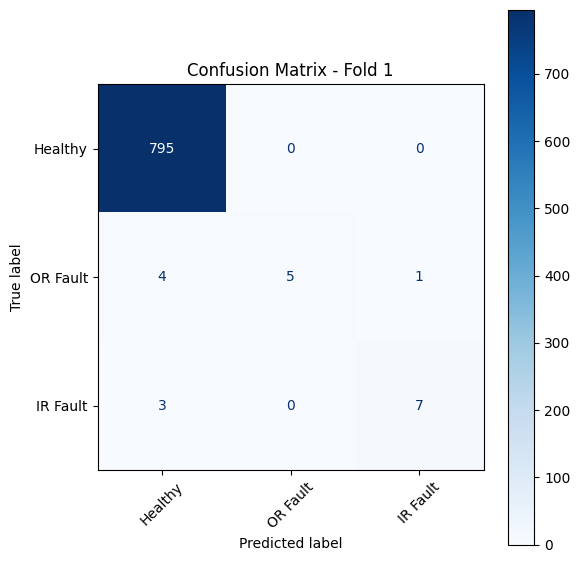

Saved confusion matrix for Fold 1 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/confusion_matrices/confusion_matrix_fold_1.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.9897 - loss: 0.0344 - val_accuracy: 0.9770 - val_loss: 0.0720
Epoch 9/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9976 - loss: 0.0076
Epoch 9: val_accuracy did not improve from 0.97696
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 0.9976 - loss: 0.0076 - val_accuracy: 0.9754 - val_loss: 0.0815
Epoch 10/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 1.0000 - loss: 0.0021
Epoch 10: val_accuracy improved from 0.97696 to 0.99386, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/best_model_fold_2.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9939 - val_loss: 0.0245
Epoch 11/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9993 - loss: 0.0023
Epoch 11: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.9993 - loss: 0.0023 - val_accuracy: 0.9923 - val_loss: 0.0278
Epoch 12/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9997 - loss: 0.0014
Epoch 12: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.9997 - loss: 0.0014 - val_accuracy: 0.9892 - val_loss: 0.0451
Epoch 13/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9994 - loss: 0.0012
Epoch 13: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 0.9994 - loss: 0.0012 - val_accuracy: 0.9846 - val_loss: 0.0924
Epoch 14/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9932 - loss: 0.0201
Epoch 14: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.9984 - loss: 0.0035 - val_accuracy: 0.9954 - val_loss: 0.0343
Epoch 18/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 1.0000 - loss: 5.7389e-04
Epoch 18: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 181ms/step - accuracy: 1.0000 - loss: 5.7438e-04 - val_accuracy: 0.9954 - val_loss: 0.0235
Epoch 19/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 1.0000 - loss: 2.6772e-04
Epoch 19: val_accuracy improved from 0.99539 to 0.99693, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/best_model_fold_2.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 1.0000 - loss: 2.6681e-04 - val_accuracy: 0.9969 - val_loss: 0.0172
Epoch 20/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 1.0000 - loss: 9.7976e-05
Epoch 20: val_accuracy improved from 0.99693 to 0.99846, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/best_model_fold_2.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 177ms/step - accuracy: 1.0000 - loss: 9.9070e-05 - val_accuracy: 0.9985 - val_loss: 0.0154
Epoch 21/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 1.0000 - loss: 1.3753e-04
Epoch 21: val_accuracy did not improve from 0.99846
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 1.0000 - loss: 1.3716e-04 - val_accuracy: 0.9985 - val_loss: 0.0166
Epoch 22/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 1.0000 - loss: 5.4574e-05
Epoch 22: val_accuracy did not improve from 0.99846
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 179ms/step - accuracy: 1.0000 - loss: 5.4640e-05 - val_accuracy: 0.9985 - val_loss: 0.0175
Epoch 23/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 1.0000 - loss: 7.7509e-05
Epoch 23: val_accuracy did not improve from 0.99846
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 175ms/step - accuracy: 1.0000 - loss: 7.7346e-05 - val_accuracy: 0.9985 - val_loss: 0.0170
Epoch 24/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 1.0000 - loss:

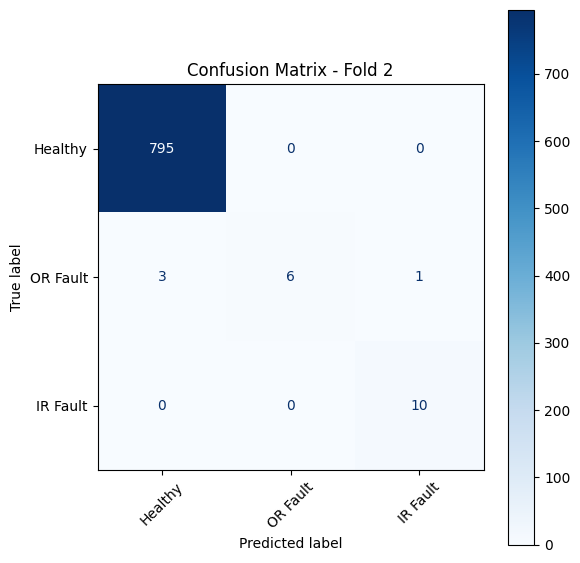

Saved confusion matrix for Fold 2 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/confusion_matrices/confusion_matrix_fold_2.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 1.0000 - loss: 3.8246e-04 - val_accuracy: 0.9939 - val_loss: 0.0226
Epoch 14/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 1.0000 - loss: 1.6710e-04
Epoch 14: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 1.0000 - loss: 1.6709e-04 - val_accuracy: 0.9939 - val_loss: 0.0202
Epoch 15/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 1.0000 - loss: 1.4931e-04
Epoch 15: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 1.0000 - loss: 1.4910e-04 - val_accuracy: 0.9939 - val_loss: 0.0204
Epoch 16/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 1.0000 - loss: 1.8100e-04
Epoch 16: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 1.0000 - loss: 1.8030e-04 - val_accuracy: 0.9939 - val_loss: 0.0175
Epoch 17/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 1.0000 - loss:

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 175ms/step - accuracy: 1.0000 - loss: 1.0246e-04 - val_accuracy: 0.9954 - val_loss: 0.0155
Epoch 18/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 1.0000 - loss: 1.1063e-04
Epoch 18: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 1.0000 - loss: 1.1019e-04 - val_accuracy: 0.9954 - val_loss: 0.0161
Epoch 19/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 1.0000 - loss: 6.5055e-05
Epoch 19: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 1.0000 - loss: 6.4880e-05 - val_accuracy: 0.9954 - val_loss: 0.0153
Epoch 20/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 1.0000 - loss: 5.0508e-05
Epoch 20: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 1.0000 - loss: 5.0489e-05 - val_accuracy: 0.9954 - val_loss: 0.0147
Epoch 21/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 1.0000 - loss:

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 1.0000 - loss: 3.1451e-05 - val_accuracy: 0.9969 - val_loss: 0.0137
Epoch 28/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 1.0000 - loss: 1.5205e-04
Epoch 28: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 1.0000 - loss: 1.5096e-04 - val_accuracy: 0.9954 - val_loss: 0.0123
Epoch 29/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 1.0000 - loss: 1.6216e-05
Epoch 29: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 1.0000 - loss: 1.6267e-05 - val_accuracy: 0.9954 - val_loss: 0.0127
Epoch 30/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 1.0000 - loss: 6.4480e-05
Epoch 30: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 1.0000 - loss: 6.3967e-05 - val_accuracy: 0.9969 - val_loss: 0.0105
Epoch 31/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 1.0000 - loss:

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 1.0000 - loss: 5.1034e-06 - val_accuracy: 0.9985 - val_loss: 0.0076
Epoch 69/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 1.0000 - loss: 3.0006e-06
Epoch 69: val_accuracy did not improve from 0.99846
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 1.0000 - loss: 2.9948e-06 - val_accuracy: 0.9985 - val_loss: 0.0096
Epoch 70/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 1.0000 - loss: 3.1236e-06
Epoch 70: val_accuracy did not improve from 0.99846
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 168ms/step - accuracy: 1.0000 - loss: 3.1133e-06 - val_accuracy: 0.9985 - val_loss: 0.0091
Epoch 71/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 1.0000 - loss: 1.1271e-06
Epoch 71: val_accuracy did not improve from 0.99846
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 1.0000 - loss: 1.1233e-06 - val_accuracy: 0.9969 - val_loss: 0.0095
Epoch 72/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 1.0000 - loss:

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 1.0000 - loss: 1.1280e-05 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 79/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 1.0000 - loss: 1.2292e-06
Epoch 79: val_accuracy did not improve from 1.00000
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 1.0000 - loss: 1.2375e-06 - val_accuracy: 0.9985 - val_loss: 0.0016
Epoch 80/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 1.0000 - loss: 1.6479e-04
Epoch 80: val_accuracy did not improve from 1.00000
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 0.9999 - loss: 2.3531e-04 - val_accuracy: 0.9754 - val_loss: 2.4928
Epoch 81/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9652 - loss: 0.2706
Epoch 81: val_accuracy did not improve from 1.00000
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 0.9653 - loss: 0.2691 - val_accuracy: 0.9754 - val_loss: 9.0819
Epoch 82/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9759 - loss: 0.0858


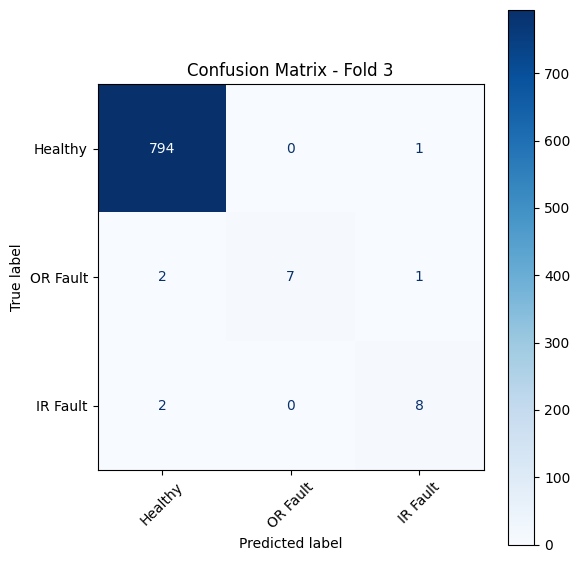

Saved confusion matrix for Fold 3 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/confusion_matrices/confusion_matrix_fold_3.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 178ms/step - accuracy: 0.9976 - loss: 0.0076 - val_accuracy: 0.9846 - val_loss: 0.0875
Epoch 10/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9893 - loss: 0.0431
Epoch 10: val_accuracy did not improve from 0.98464
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 0.9894 - loss: 0.0429 - val_accuracy: 0.9816 - val_loss: 0.1018
Epoch 11/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9927 - loss: 0.0184
Epoch 11: val_accuracy improved from 0.98464 to 0.98618, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/best_model_fold_4.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 182ms/step - accuracy: 0.9927 - loss: 0.0183 - val_accuracy: 0.9862 - val_loss: 0.0697
Epoch 12/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9978 - loss: 0.0116
Epoch 12: val_accuracy did not improve from 0.98618
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 192ms/step - accuracy: 0.9978 - loss: 0.0116 - val_accuracy: 0.8233 - val_loss: 0.4142
Epoch 13/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9983 - loss: 0.0061
Epoch 13: val_accuracy did not improve from 0.98618
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - accuracy: 0.9983 - loss: 0.0061 - val_accuracy: 0.9846 - val_loss: 0.0568
Epoch 14/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9980 - loss: 0.0068
Epoch 14: val_accuracy did not improve from 0.98618
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 178ms/step - accuracy: 0.9980 - loss: 0.0068 - val_accuracy: 0.9186 - val_loss: 0.2543
Epoch 15/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 1.0000 - loss: 0.0024
Epoch 15: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 204ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.9892 - val_loss: 0.0225
Epoch 16/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 1.0000 - loss: 6.6096e-04
Epoch 16: val_accuracy improved from 0.98925 to 0.99232, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/best_model_fold_4.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 189ms/step - accuracy: 1.0000 - loss: 6.5960e-04 - val_accuracy: 0.9923 - val_loss: 0.0214
Epoch 17/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 1.0000 - loss: 6.8648e-04
Epoch 17: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 1.0000 - loss: 6.8169e-04 - val_accuracy: 0.9908 - val_loss: 0.0318
Epoch 18/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 1.0000 - loss: 4.0228e-04
Epoch 18: val_accuracy improved from 0.99232 to 0.99539, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/best_model_fold_4.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 177ms/step - accuracy: 1.0000 - loss: 4.0037e-04 - val_accuracy: 0.9954 - val_loss: 0.0167
Epoch 19/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 1.0000 - loss: 2.6057e-04
Epoch 19: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 178ms/step - accuracy: 1.0000 - loss: 2.6047e-04 - val_accuracy: 0.9954 - val_loss: 0.0211
Epoch 20/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 1.0000 - loss: 1.0120e-04
Epoch 20: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 182ms/step - accuracy: 1.0000 - loss: 1.0097e-04 - val_accuracy: 0.9939 - val_loss: 0.0280
Epoch 21/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 1.0000 - loss: 3.5326e-05
Epoch 21: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 1.0000 - loss: 3.5404e-05 - val_accuracy: 0.9954 - val_loss: 0.0246
Epoch 22/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 1.0000 - loss:

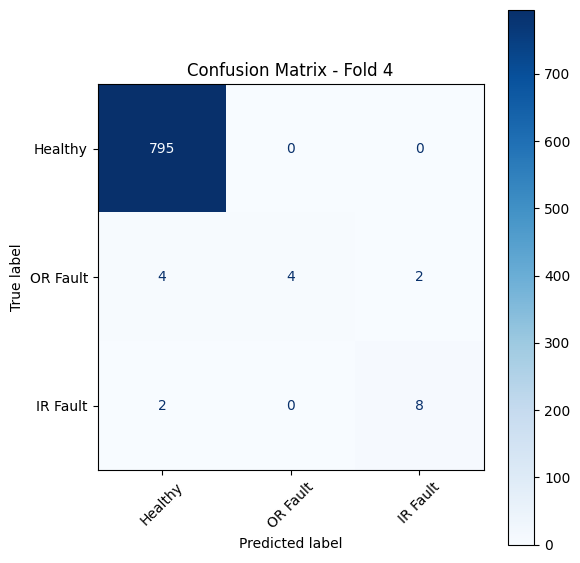

Saved confusion matrix for Fold 4 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/confusion_matrices/confusion_matrix_fold_4.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,867 (1.17 MB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 0.9996 - loss: 0.0057 - val_accuracy: 0.9923 - val_loss: 0.0269
Epoch 12/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9996 - loss: 0.0018
Epoch 12: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 178ms/step - accuracy: 0.9996 - loss: 0.0018 - val_accuracy: 0.9908 - val_loss: 0.0120
Epoch 13/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 1.0000 - loss: 3.4522e-04
Epoch 13: val_accuracy improved from 0.99232 to 0.99539, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/best_model_fold_5.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 1.0000 - loss: 3.4421e-04 - val_accuracy: 0.9954 - val_loss: 0.0093
Epoch 14/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 1.0000 - loss: 2.0949e-04
Epoch 14: val_accuracy improved from 0.99539 to 0.99693, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/best_model_fold_5.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 1.0000 - loss: 2.0937e-04 - val_accuracy: 0.9969 - val_loss: 0.0067
Epoch 15/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 1.0000 - loss: 1.5376e-04
Epoch 15: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 179ms/step - accuracy: 1.0000 - loss: 1.5348e-04 - val_accuracy: 0.9954 - val_loss: 0.0074
Epoch 16/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 1.0000 - loss: 2.2074e-04
Epoch 16: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 175ms/step - accuracy: 1.0000 - loss: 2.2093e-04 - val_accuracy: 0.9969 - val_loss: 0.0065
Epoch 17/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 1.0000 - loss: 1.0718e-04
Epoch 17: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 1.0000 - loss: 1.0694e-04 - val_accuracy: 0.9969 - val_loss: 0.0049
Epoch 18/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 1.0000 - loss:

82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 1.0000 - loss: 8.2465e-05 - val_accuracy: 0.9985 - val_loss: 0.0042
Epoch 19/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 1.0000 - loss: 5.5606e-05
Epoch 19: val_accuracy improved from 0.99846 to 1.00000, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/best_model_fold_5.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 1.0000 - loss: 5.5499e-05 - val_accuracy: 1.0000 - val_loss: 0.0041
Epoch 20/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 1.0000 - loss: 8.6830e-05
Epoch 20: val_accuracy did not improve from 1.00000
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 1.0000 - loss: 8.6664e-05 - val_accuracy: 0.9985 - val_loss: 0.0042
Epoch 21/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 1.0000 - loss: 1.1530e-04
Epoch 21: val_accuracy did not improve from 1.00000
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 1.0000 - loss: 1.1511e-04 - val_accuracy: 0.9985 - val_loss: 0.0045
Epoch 22/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 1.0000 - loss: 4.1185e-05
Epoch 22: val_accuracy did not improve from 1.00000
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 1.0000 - loss: 4.1093e-05 - val_accuracy: 0.9985 - val_loss: 0.0042
Epoch 23/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 1.0000 - loss:

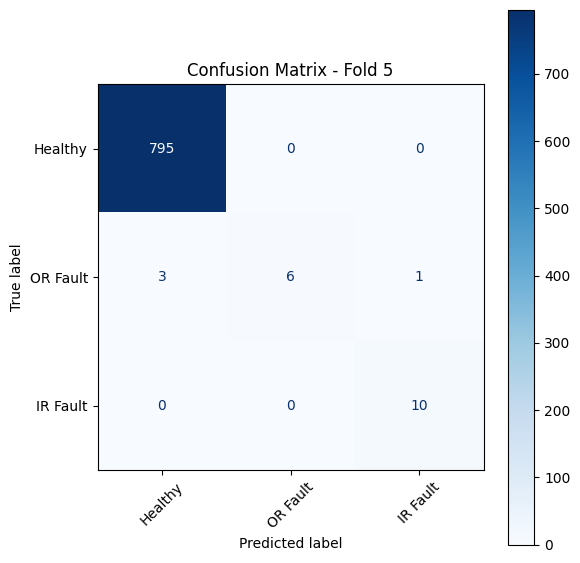

Saved confusion matrix for Fold 5 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/confusion_matrices/confusion_matrix_fold_5.png
Total Computation Time: 13725.30 seconds (228.75 minutes)


In [23]:
# Training with k-fold validation
kSplits = 5
accuracy_2D = []
precision_2D = []
recall_2D = []
f1_2D = []
log_loss_2D = []
balanced_accuracy_2D = []
precision_2D_macro = []
recall_2D_macro = []
f1_2D_macro = []
accuracy_2D_test = []
precision_2D_test = []
recall_2D_test = []
log_loss_2D_test = []
f1_2D_test = []
precision_2D_test_macro = []
recall_2D_test_macro = []
f1_2D_test_macro = []
balanced_accuracy_2D_test = []
# accuracy_val = []

foldername = "Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer/"

condition_map = {
    0: "Healthy",
    1: "OR Fault",
    2: "IR Fault"
}

early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
start_time = time.time()
y_labels = np.argmax(y_train_positional_split, axis=1)

kfold = StratifiedKFold(n_splits=kSplits, random_state=32, shuffle=True)

for fold, (train_idx, test_idx) in enumerate(kfold.split(X_2D_train, y_labels)):

    Classification_2D = CNN_2D()

    checkpoint_filepath = os.path.join(foldername, f"best_model_fold_{fold+1}.h5")
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    )

    Classification_2D.model.fit(X_2D_train[train_idx], y_train_positional_split[train_idx],
                                validation_data=(X_2D_train[test_idx], y_train_positional_split[test_idx]),
                                epochs=200, callbacks=[early_stopping, checkpoint], verbose=1)

    print(f"Best model for Fold {fold+1} saved to: {checkpoint_filepath}")

    # Train set metrics
    y_pred_proba_train = Classification_2D.model.predict(X_2D_train)
    y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    y_true_train = np.argmax(y_train_positional_split, axis=1)

    accuracy_2D.append(accuracy_score(y_true_train, y_pred_train))
    precision_2D.append(precision_score(y_true_train, y_pred_train, average='weighted'))
    recall_2D.append(recall_score(y_true_train, y_pred_train, average='weighted'))
    f1_2D.append(f1_score(y_true_train, y_pred_train, average='weighted'))
    log_loss_2D.append(log_loss(y_true_train, y_pred_proba_train))
    balanced_accuracy_2D.append(balanced_accuracy_score(y_true_train, y_pred_train))
    precision_2D_macro.append(precision_score(y_true_train, y_pred_train, average='macro'))
    recall_2D_macro.append(recall_score(y_true_train, y_pred_train, average='macro'))
    f1_2D_macro.append(f1_score(y_true_train, y_pred_train, average='macro'))

    # Test set metrics
    y_pred_proba_test = Classification_2D.model.predict(X_2D_test)
    y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    y_true_test = np.argmax(y_test_positional_split, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[condition_map[i] for i in range(3)])
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
    plt.title(f'Confusion Matrix - Fold {fold + 1}')
    plt.grid(False)
    plt.tight_layout()

    # Save confusion matrix
    save_dir = os.path.join(foldername, "confusion_matrices")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"confusion_matrix_fold_{fold + 1}.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved confusion matrix for Fold {fold + 1} at: {save_path}")

    # accuracy_val.append(accuracy_score(X_2D_train[test_idx], y_train_positional_split[test_idx]))
    accuracy_2D_test.append(accuracy_score(y_true_test, y_pred_test))
    precision_2D_test.append(precision_score(y_true_test, y_pred_test, average='weighted'))
    recall_2D_test.append(recall_score(y_true_test, y_pred_test, average='weighted'))
    f1_2D_test.append(f1_score(y_true_test, y_pred_test, average='weighted'))
    precision_2D_test_macro.append(precision_score(y_true_test, y_pred_test, average='macro'))
    recall_2D_test_macro.append(recall_score(y_true_test, y_pred_test, average='macro'))
    f1_2D_test_macro.append(f1_score(y_true_test, y_pred_test, average='macro'))
    log_loss_2D_test.append(log_loss(y_true_test, y_pred_proba_test))
    balanced_accuracy_2D_test.append(balanced_accuracy_score(y_true_test, y_pred_test))

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total Computation Time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")


In [28]:
# Aggregated metrics
CNN_2D_train_accuracy = np.mean(accuracy_2D) * 100
CNN_2D_test_accuracy = np.mean(accuracy_2D_test) * 100
CNN_2D_train_precision = np.mean(precision_2D) * 100
CNN_2D_test_precision = np.mean(precision_2D_test) * 100
CNN_2D_train_recall = np.mean(recall_2D) * 100
CNN_2D_test_recall = np.mean(recall_2D_test) * 100
CNN_2D_train_f1 = np.mean(f1_2D) * 100
CNN_2D_test_f1 = np.mean(f1_2D_test) * 100
CNN_2D_train_precision_macro = np.mean(precision_2D_macro) * 100
CNN_2D_train_recall_macro = np.mean(recall_2D_macro) * 100
CNN_2D_train_f1_macro = np.mean(f1_2D_macro) * 100
CNN_2D_test_precision_macro = np.mean(precision_2D_test_macro) * 100
CNN_2D_test_recall_macro = np.mean(recall_2D_test_macro) * 100
CNN_2D_test_f1_macro = np.mean(f1_2D_test_macro) * 100
CNN_2D_train_log_loss = np.mean(log_loss_2D)
CNN_2D_test_log_loss = np.mean(log_loss_2D_test)
CNN_2D_train_balanced_accuracy = np.mean(balanced_accuracy_2D) * 100
CNN_2D_test_balanced_accuracy = np.mean(balanced_accuracy_2D_test) * 100
# CNN_2D_val_accuracy = np.mean(accuracy_val) * 100

# Print metrics
print(f"Train Accuracy: {CNN_2D_train_accuracy:.2f}%")
print(f"Test Accuracy: {CNN_2D_test_accuracy:.2f}%")
print(f"Train Precision: {CNN_2D_train_precision:.2f}%")
print(f"Test Precision: {CNN_2D_test_precision:.2f}%")
print(f"Train Recall: {CNN_2D_train_recall:.2f}%")
print(f"Test Recall: {CNN_2D_test_recall:.2f}%")
print(f"Train F1: {CNN_2D_train_f1:.2f}%")
print(f"Test F1: {CNN_2D_test_f1:.2f}%")
print(f"Train Log Loss: {CNN_2D_train_log_loss:.4f}")
print(f"Test Log Loss: {CNN_2D_test_log_loss:.4f}")
print(f"Train Balanced Accuracy: {CNN_2D_train_balanced_accuracy:.2f}%")
print(f"Test Balanced Accuracy: {CNN_2D_test_balanced_accuracy:.2f}%")

print(f"Train Precision (Macro): {CNN_2D_train_precision_macro:.2f}%")
print(f"Train Recall (Macro): {CNN_2D_train_recall_macro:.2f}%")
print(f"Train F1 Score (Macro): {CNN_2D_train_f1_macro:.2f}%")

print(f"Test Precision (Macro): {CNN_2D_test_precision_macro:.2f}%")
print(f"Test Recall (Macro): {CNN_2D_test_recall_macro:.2f}%")
print(f"Test F1 Score (Macro): {CNN_2D_test_f1_macro:.2f}%")

# print(f"CNN_2D_val_accuracy: {CNN_2D_val_accuracy:.2f}%")


Train Accuracy: 99.96%
Test Accuracy: 99.26%
Train Precision: 99.96%
Test Precision: 99.27%
Train Recall: 99.96%
Test Recall: 99.26%
Train F1: 99.96%
Test F1: 99.18%
Train Log Loss: 0.0029
Test Log Loss: 0.0412
Train Balanced Accuracy: 98.83%
Test Balanced Accuracy: 80.66%
Train Precision (Macro): 99.99%
Train Recall (Macro): 98.83%
Train F1 Score (Macro): 99.40%
Test Precision (Macro): 95.10%
Test Recall (Macro): 80.66%
Test F1 Score (Macro): 85.53%


102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step


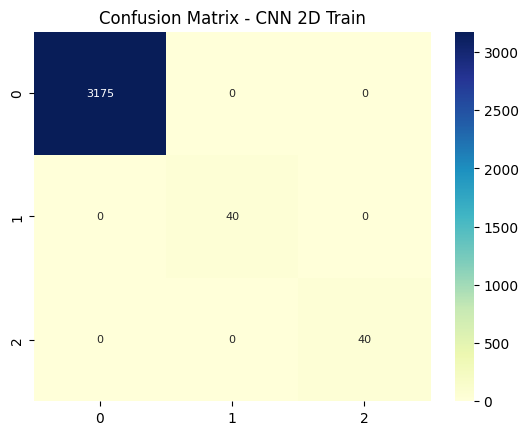

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


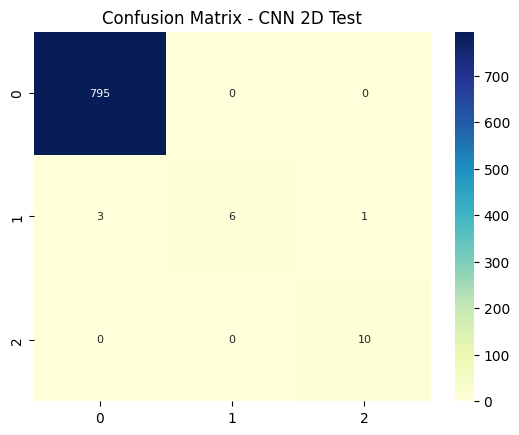

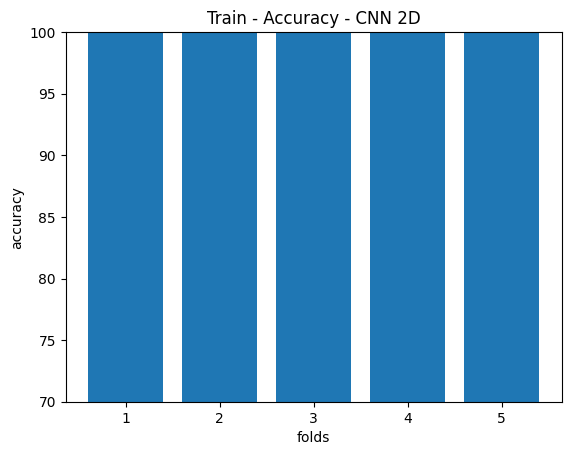

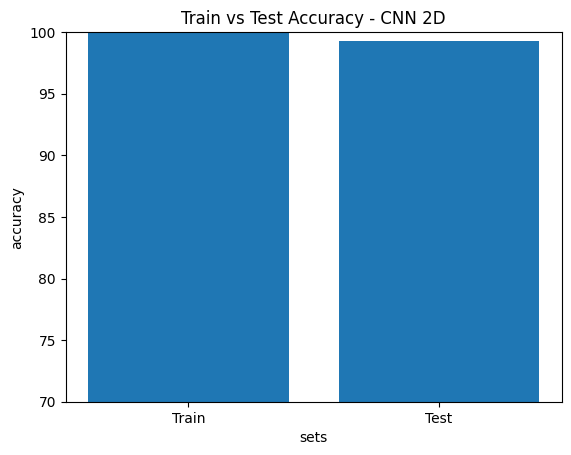

In [25]:
# Confusion Matrix Calculation
def ConfusionMatrix(Model, X, y):
    y_pred_proba = Model.model.predict(X)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y, axis=1)
    return confusion_matrix(y_true, y_pred)

# Plot results - CNN 2D
plt.figure(1)
plt.title('Confusion Matrix - CNN 2D Train')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_train, y_train_positional_split),
            annot=True, fmt='d', annot_kws={"fontsize": 8}, cmap="YlGnBu")
plt.show()

plt.figure(2)
plt.title('Confusion Matrix - CNN 2D Test')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_test, y_test_positional_split),
            annot=True, fmt='d', annot_kws={"fontsize": 8}, cmap="YlGnBu")
plt.show()

plt.figure(3)
plt.title('Train - Accuracy - CNN 2D')
plt.bar(np.arange(1, kSplits + 1), [i * 100 for i in accuracy_2D])
plt.ylabel('accuracy')
plt.xlabel('folds')
plt.ylim([70, 100])
plt.show()

plt.figure(4)
plt.title('Train vs Test Accuracy - CNN 2D')
plt.bar([1, 2], [CNN_2D_train_accuracy, CNN_2D_test_accuracy])
plt.ylabel('accuracy')
plt.xlabel('sets')
plt.xticks([1, 2], ['Train', 'Test'])
plt.ylim([70, 100])
plt.show()
